<a href="https://colab.research.google.com/github/Presto5572/Fina-os/blob/main/modeling/modeling_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# This is cloning Pearl's Github repository that has the dataset.
!git clone https://github.com/pearl-yu/mist5400spring2026.git
%cd mist5400spring2026/modeling/

Cloning into 'mist5400spring2026'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 41 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 102.06 KiB | 1.34 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/mist5400spring2026/modeling/mist5400spring2026/modeling


A few tips

- IF OPENING IN COLAB, REMEMBER TO SAVE THIS NOTEBOOK TO GOOGLE DRIVE!

- If you refresh the page, you'd need to run the notebook from the top again.

- If Gemini starts to generate answers in the chat mode and stopped generate code into code cells: Start a new Gemini chat and try again; Sometimes if the task is too complex, Gemini enters an agent mode that makes a plan of multiple steps. It'll compile severl code cells at the end of the notebook.

# Implementing a complete DS/AI project

Over the past two weeks, we’ve covered the complete data science and AI workflow. We’ll wrap up by implementing the full pipeline in code.


Goals:
- Become familiar with core **modeling procedures**: define a model, training, and evaluation.
- Practice loading datasets and generating descriptive statistics / visualizations.
- Play with Gemini to better understand the **range and limitations of generative AI outputs**, and how different ** prompts** shape those outputs in standard AI projects.


# Predicting Churn

After discussing the churn problem, you've finally defined an adequate target variable for churn and gathered relevant data to predict it. Keeping it simple for the sake of this course, we'd like to predict is without sending an offer, who're going to churn.

It is your job to use data from previous contract expirations to build a churn predictive model to predict who're the most likely to churn. You have assembled the best historical data set you can at this point, which includes:

- Gender: Whether the customer is a male or a female
- SeniorCitizen: Whether the customer is a senior citizen or not (1, 0)
- Partner: Whether the customer has a partner or not (Yes, No)
- Dependents: Whether the customer has dependents or not (Yes, No)
- tenure: Number of months the customer has stayed with the company
- PhoneService: Whether the customer has a phone service or not (Yes, No)
- MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
- InternetService: Customer’s internet service provider (DSL, Fiber optic, No)
- OnlineSecurity: Whether the customer has online security or not (Yes, No, No internet service)
- OnlineBackup: Whether the customer has online backup or not (Yes, No, No internet service)
- DeviceProtection: Whether the customer has device protection or not (Yes, No, No internet service)
- TechSupport: Whether the customer has tech support or not (Yes, No, No internet service)
- StreamingTV: Whether the customer has streaming TV or not (Yes, No, No internet service)
- StreamingMovies: Whether the customer has streaming movies or not (Yes, No, No internet service)
- Contract: The contract term of the customer (Month-to-month, One year, Two year)
- PaperlessBilling: Whether the customer has paperless billing or not (Yes, No)
- PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- MonthlyCharges: The amount charged to the customer monthly
- Churn: Whether the customer churned or not shortly after contract expiration (Yes or No)

## Step 1. Load the churn data, Preprocessing, Initial exploration

### 1a. Load data
Since we cloned the github repo, we could read in the dataset directly.

In [6]:
import numpy as np
import pandas as pd

# If necessary change the path below so that it points to your file.
df = pd.read_csv("churn_data.csv")

Let's preview the dataset first.

If you don't remember the code, here's a prompt you could try: preview the dataset

In [7]:
# If necessary change the path below so that it points to your file.
df = pd.read_csv("churn_data.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes


Some pre-processing we need to do..some of the features are categorical, so we need to convert them into dummies.  We can do this using the function `get_dummies` from `Pandas`.

In [8]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,True


### 1b. Initial Exlporation

I'd like to take a look at the target variable first.

Here's a prompt you could try: Show me the disribution of the target variable Churn_Yes.

In [10]:
print(df['Churn_Yes'].value_counts())
print(df['Churn_Yes'].value_counts(normalize=True))

Churn_Yes
False    5163
True     1869
Name: count, dtype: int64
Churn_Yes
False    0.734215
True     0.265785
Name: proportion, dtype: float64


So we have a bunch of features. What might be predictive of a customer churning? We could check the correlations with a heatmap.

Here's a prompt to try:
My target variable is Churn_Yes.Show me the correlations between the features and the target variable with a heatmap.

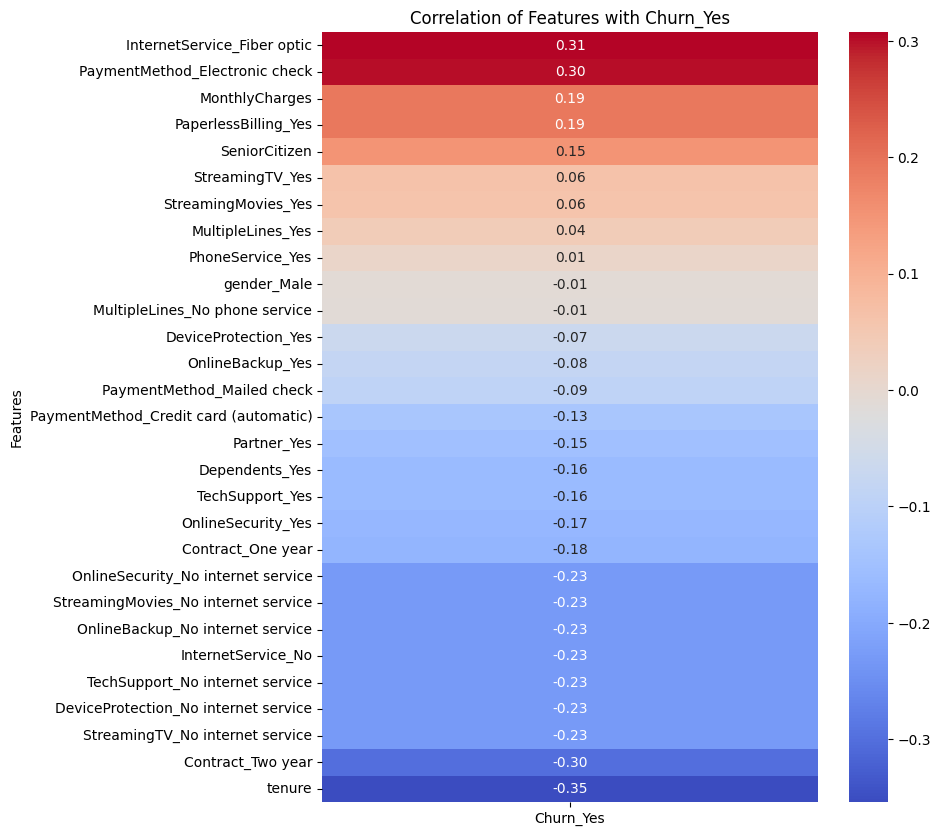

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlations with the target variable 'Churn_Yes'
correlations = df.corr()['Churn_Yes'].sort_values(ascending=False)

# Drop the target variable itself from the correlation list for plotting
correlations = correlations.drop('Churn_Yes')

# Plotting the correlations
plt.figure(figsize=(8, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation of Features with Churn_Yes')
plt.ylabel('Features')
plt.show()

## Step 2. Build A Logistic Regression Model

### 2a. Split the data into 80% training data and 20% test data.

Test data, is the same thing as validation set, holdout set. Basically it's a small portion of data that the model isn't trained on so we could use this small portion to evaluate out-of-sample performances.

Here's a prompt to try:   
Split df into training and testing set (20%).


In [13]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 5625
Testing set size: 1407


OK. Let's read the generated code. So we do need to specify what portion of data we'd like to put into the testing set. Automatically Gemini chose what proportion?

### 2b. Define the model(s)

Let's try logistic regression first.

Prompt: define a logistic regression model

In [14]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for smaller datasets and good for L1/L2 regularization

Defining the model also need us to tell it what's the target variable and what're the features.

### 2c. Train the model

Here's a prompt to try:
Fit the defined logistic regression to the training set.

In [16]:
log_reg_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

### 2d. Evaluate the model performances

Here's a prompt to try:    
Make predictions on the training and testing set.



In [18]:
y_train_pred = log_reg_model.predict(X_train)
y_test_pred = log_reg_model.predict(X_test)

Now there could be many evaluation metrics. Let's just ask the GenAI tool to compare performance and see what default metrics it chooses.

Here's a prompt to try:    
Can you compare the performance on the training and testing set?

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate performance on the training set
print("--- Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")

print("\n--- Testing Set Performance ---")
# Evaluate performance on the testing set
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

--- Training Set Performance ---
Accuracy: 0.8060
Precision: 0.6603
Recall: 0.5565
F1-Score: 0.6040

--- Testing Set Performance ---
Accuracy: 0.7918
Precision: 0.6294
Recall: 0.5267
F1-Score: 0.5735


Optional: There're other metrics such as cross-entropy, and confusion matrix. You could ask Gemini to explain these metrics and compare.

### 2e. Changing the threshold

Remember that the logistic regression is trained to output probabilities from 0 to 1. When making predictions of the class, we need to choose a threshold.

When we run this line of code to make predictions
`y_train_pred = log_reg_model.predict(X_train)`,
the package chose a default threshold. What is it?

Prompt: With the logistic regression, I didn't choose the cutoff. is there a cutoff chosen?

Paste the output below.

In [20]:
# Get predicted probabilities for the first few samples of the training set
y_train_proba_sample = log_reg_model.predict_proba(X_train.head())[:, 1]

# Get default predictions for the same samples
y_train_pred_sample = log_reg_model.predict(X_train.head())

print("Predicted Probabilities (Churn_Yes):")
print(y_train_proba_sample)
print("\nDefault Predictions (Cutoff 0.5):")
print(y_train_pred_sample)
print("\nConfirming default 0.5 cutoff:")
print((y_train_proba_sample >= 0.5) == y_train_pred_sample)


Predicted Probabilities (Churn_Yes):
[0.32357275 0.35302284 0.32615467 0.01114871 0.10808806]

Default Predictions (Cutoff 0.5):
[False False False False False]

Confirming default 0.5 cutoff:
[ True  True  True  True  True]


Now if we change the cutoff, would accuracy improve?

Prompt: Choose the cutoff that has the highest training accuracy.

In [21]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get predicted probabilities for the training set
y_train_proba = log_reg_model.predict_proba(X_train)[:, 1]

# Initialize variables to store best accuracy and cutoff
best_accuracy = 0
best_cutoff = 0

# Iterate through a range of possible cutoffs (e.g., 0.0 to 1.0 with small steps)
for cutoff in np.arange(0.0, 1.01, 0.01):
    # Convert probabilities to binary predictions based on the current cutoff
    y_train_pred_cutoff = (y_train_proba >= cutoff).astype(bool)

    # Calculate accuracy for the current cutoff
    accuracy = accuracy_score(y_train, y_train_pred_cutoff)

    # Check if this cutoff yields a higher accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_cutoff = cutoff

print(f"Optimal cutoff for highest training accuracy: {best_cutoff:.2f}")
print(f"Highest training accuracy at this cutoff: {best_accuracy:.4f}")

Optimal cutoff for highest training accuracy: 0.55
Highest training accuracy at this cutoff: 0.8119


## Step 3: Model Selection

Now let's build multiple models and compare the performances to find the best model.

Prompt: Aside from logistic regression, are there other models suitable for the task?

Paste the answers in the text cell below.

Let's pick random forest and see which is a better model.

Here's a prompt to try:
Build a random forest model and compare performances of the logistic regression and the random forest model.

# In-class exercise

Just complete this notebook. Download it as a .ipynb file, submit under the Assignment tab ->In-class exercise 2.

# Task
Build and evaluate a Random Forest model for churn prediction using `X_train`, `y_train`, `X_test`, and `y_test`. After training and making predictions, calculate and display the accuracy, precision, recall, and F1-score for both the training and testing sets for the Random Forest model. Finally, compare these metrics with the previously calculated metrics for the Logistic Regression model to determine which model performs better.

## Build and Evaluate Random Forest

### Subtask:
Import RandomForestClassifier, define and train the model on X_train and y_train, make predictions on X_train and X_test, and calculate accuracy, precision, recall, and F1-score for both training and testing sets.


**Reasoning**:
To build and evaluate the Random Forest model, I need to import the necessary class, instantiate it, train it on the training data, make predictions, and then calculate and print the performance metrics for both training and testing sets.



In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate the Random Forest Classifier
random_forest_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
random_forest_model.fit(X_train, y_train)

# Make predictions on the training and testing sets
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

# Evaluate performance on the training set
print("--- Random Forest Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_rf):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred_rf):.4f}")

print("\n--- Random Forest Testing Set Performance ---")
# Evaluate performance on the testing set
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_rf):.4f}")

--- Random Forest Training Set Performance ---
Accuracy: 0.9973
Precision: 0.9960
Recall: 0.9940
F1-Score: 0.9950

--- Random Forest Testing Set Performance ---
Accuracy: 0.7719
Precision: 0.5911
Recall: 0.4599
F1-Score: 0.5173


### Comparison of Model Performances

Let's compare the performance metrics for both Logistic Regression and Random Forest models.

**Logistic Regression Performance:**
- **Training Set:**
  - Accuracy: 0.8060
  - Precision: 0.6603
  - Recall: 0.5565
  - F1-Score: 0.6040
- **Testing Set:**
  - Accuracy: 0.7918
  - Precision: 0.6294
  - Recall: 0.5267
  - F1-Score: 0.5735

**Random Forest Performance:**
- **Training Set:**
  - Accuracy: 0.9973
  - Precision: 0.9960
  - Recall: 0.9940
  - F1-Score: 0.9950
- **Testing Set:**
  - Accuracy: 0.7719
  - Precision: 0.5911
  - Recall: 0.4599
  - F1-Score: 0.5173

**Analysis:**

1.  **Training Set Performance:** The Random Forest model shows significantly higher performance on the training set across all metrics (Accuracy, Precision, Recall, F1-Score) compared to Logistic Regression. This suggests that the Random Forest model is much better at fitting the training data, potentially indicating overfitting.
2.  **Testing Set Performance:** On the testing set, which is a better indicator of generalization ability:
    - **Accuracy:** Logistic Regression (0.7918) has a slightly higher accuracy than Random Forest (0.7719).
    - **Precision:** Logistic Regression (0.6294) has higher precision than Random Forest (0.5911).
    - **Recall:** Logistic Regression (0.5267) also has higher recall than Random Forest (0.4599).
    - **F1-Score:** Logistic Regression (0.5735) has a better F1-score than Random Forest (0.5173).

**Conclusion:**

While Random Forest exhibits excellent performance on the training data, it shows a noticeable drop in performance on the testing data, indicating **overfitting**. The Logistic Regression model, although performing lower on the training set, demonstrates more consistent and slightly better generalization performance on the unseen test data across all evaluated metrics. Therefore, for this particular dataset and current parameters, the **Logistic Regression model appears to be the better model** due to its superior generalization capabilities and less overfitting.

## Compare Model Performances

### Subtask:
Present a side-by-side comparison of the performance metrics (Accuracy, Precision, Recall, F1-Score) for both the Logistic Regression and Random Forest models on both training and testing sets to identify the better-performing model.


## Summary:

### Q&A
The Logistic Regression model performed better than the Random Forest model for churn prediction based on the evaluated metrics on the test dataset.

### Data Analysis Key Findings
*   The Random Forest model demonstrated excellent performance on the training set, achieving an Accuracy of 0.9973, Precision of 0.9960, Recall of 0.9940, and an F1-Score of 0.9950.
*   However, the Random Forest model's performance significantly decreased on the testing set, with an Accuracy of 0.7719, Precision of 0.5911, Recall of 0.4599, and an F1-Score of 0.5173, indicating overfitting.
*   The Logistic Regression model showed more consistent performance across both training and testing sets. On the testing set, it achieved an Accuracy of 0.7918, Precision of 0.6294, Recall of 0.5267, and an F1-Score of 0.5735.
*   Comparing the testing set performances, the Logistic Regression model outperformed the Random Forest model across all key metrics (Accuracy, Precision, Recall, and F1-Score), demonstrating better generalization to unseen data.

### Insights or Next Steps
*   The Random Forest model's significant overfitting suggests that hyperparameter tuning or regularization techniques are necessary to improve its generalization ability before considering it a viable option.
*   Given its superior performance and better generalization on the test data, the Logistic Regression model is currently the more suitable choice for churn prediction in this context.
